# 第052讲 无泄漏的数据处理流水线

先追踪参数和标签来源，再读分数。A新设备、B纯噪声选择、C独立类别编码是三种不同机制；不要把分数差混成一种因果影响。按顺序从新内核运行。

In [1]:
from pathlib import Path
import hashlib, json, sys
ROOT = Path.cwd().resolve()
EXPECTED = {'experiment.py': 'c4e32c9fa4a8e97ea5cac9f9099a8ddf12c9aa1f43ea40e919548e58d861a9ca', 'audit.py': '4f12ae897304703aa390be86a47654c2362615eb8a29502ac96473ebd6fcbf6a', 'plots.py': '7e684087242a5659bed788f2e9db234fc7cf4cfedf2f00d6f750a1b7ab62b626', 'data_integrity.json': 'e4c4b1526abef612fe2d6714143a3b79759061c01803b37822494019951ebb7d', 'data/draws.npz': 'f272072181615bd3d924957152c0a7d540dc692be8c8c0ffc5ba270c83957a99', 'data/encoding_example.csv': 'c98b6246519775bf3be86da7e8935908b8d6c697cc72aed655b3165b0f578211', 'data/group_example.csv': '920cd692e1f3d37ac71e0e4afae0d46e375d1df42399849e43f423ace96f40b6', 'data/hand.csv': '53101cf67c9c3da23d59233a74620277c6f956bea36534db471c065f3a98b22b', 'data/protocol.json': 'd4b47aab981963dcd7bc6a3511f1b94e42a2d542f5342630d6ab09b50f1dce12', 'data/split_membership.csv': '2ed18fdde45ae196e68541161f7cafc3da60f0f2c46c4e432afa43ecdf06fb3a', 'data/splits.npz': 'c27554634c348e47b46f33dd356147f69af5a83ea102a889412b743aab9dace1'}
for name, digest in EXPECTED.items():
    path = ROOT/name
    if not path.is_file() or hashlib.sha256(path.read_bytes()).hexdigest()!=digest:
        raise RuntimeError("Missing or modified teaching input: "+name)
print("Verified",len(EXPECTED),"source/data files")

Verified 11 source/data files


## 1 固定协议与版本

数值只从随包数据读取。A全缺列保留并填0，站点无缺失；未知类别回退明确。C连续目标显式声明，不让整数回归标签自动变成分类。

In [2]:
import numpy as np
import scipy, sklearn, matplotlib, nbformat, ipykernel
import experiment as e
import audit, plots
from IPython.display import display, Image
print({"python":sys.version.split()[0],"numpy":np.__version__,"scipy":scipy.__version__,"sklearn":sklearn.__version__,"matplotlib":matplotlib.__version__,"nbformat":nbformat.__version__,"ipykernel":ipykernel.__version__})
c,d,splits = e.load_data()
print(json.dumps(c,ensure_ascii=False,indent=2))

{'python': '3.12.14', 'numpy': '2.3.5', 'scipy': '1.17.0', 'sklearn': '1.8.0', 'matplotlib': '3.10.8', 'nbformat': '5.11.1', 'ipykernel': '7.4.0'}
{
  "unit": "052",
  "fixed_before_first_score": true,
  "data_seed": 52017,
  "outer_seed": 52031,
  "encoder_seed": 52043,
  "independent_repetitions": 12,
  "outer_folds": 4,
  "group_experiment": {
    "devices": 48,
    "rows_per_device": 6,
    "numeric_features": 2,
    "device_sd": 0.8,
    "noise_sd": 0.6,
    "missing_rate": [
      0.18,
      0.12
    ],
    "contamination_rate": 0.04,
    "contamination_shift": 12.0,
    "clip_quantiles": [
      0.05,
      0.95
    ],
    "ridge_alpha": 15.0,
    "target": "new independent devices during the same observation regime; no time forecasting claim",
    "comparison": "change scaler fit scope only; median imputer, clip bounds, one-hot vocabulary stay outer-training-only"
  },
  "selection_experiment": {
    "rows": 200,
    "noise_features": 300,
    "selected_features": 5,
    "ridg

## 2 从四行原值到同步更新

中位数3，上下界1与5，均值3，方差2。设计顺序b,z,A,B,missing。检查每行损失和局部导数，再求和除4；η=1/5。H5/H6仅前向，不给训练标签。

In [3]:
h = e.hand()
print(h["statistics"])
for row in h["rows"]:
    print(row)
print("Gradient",h["gradient_mean"],"updated theta",h["theta_next"])
print("Next half loss",h["next_half_loss"],"validation predictions",h["valid_next_prediction"])
print("Independent fractions",audit.exact_hand())

{'median': 3.0, 'clip_range': [1.0, 5.0], 'mean': 3.0, 'variance_ddof0': 2.0, 'scale': 1.4142135623730951, 'category_vocabulary': ['A', 'B'], 'fit_rows': ['H1', 'H2', 'H3', 'H4']}
{'id': 'H1', 'raw_x': 1.0, 'category': 'A', 'imputed': 1.0, 'clipped': 1.0, 'scaled': -1.414213562373095, 'design': [1.0, -1.414213562373095, 1.0, 0.0, 0.0], 'y': 1.0, 'prediction': 0.0, 'half_loss': 0.5, 'local_derivatives': [-1.0, 1.414213562373095, -1.0, -0.0, -0.0], 'next_prediction': 0.25000000000000006, 'next_half_loss': 0.28125}
{'id': 'H2', 'raw_x': None, 'category': 'A', 'imputed': 3.0, 'clipped': 3.0, 'scaled': 0.0, 'design': [1.0, 0.0, 1.0, 0.0, 1.0], 'y': 2.0, 'prediction': 0.0, 'half_loss': 2.0, 'local_derivatives': [-2.0, -0.0, -2.0, -0.0, -2.0], 'next_prediction': 0.75, 'next_half_loss': 0.78125}
{'id': 'H3', 'raw_x': 3.0, 'category': 'B', 'imputed': 3.0, 'clipped': 3.0, 'scaled': 0.0, 'design': [1.0, 0.0, 0.0, 1.0, 0.0], 'y': 2.0, 'prediction': 0.0, 'half_loss': 2.0, 'local_derivatives': [-2.0

## 3 一个实际训练折的统计来源

每折216行来自36设备；72行来自12个新设备。组ID只做划分，不做特征。类别站点共享合法，设备身份交叉不符合此目标。

In [4]:
X = e.group_X(d,0); y=d["group_y"][0]
tr=splits["group_0_train"]; va=splits["group_0_valid"]
pipe=e.make_pipeline().fit(X[tr],y[tr])
print(e.state(pipe["pre"],tr))
print(pipe["pre"].get_feature_names_out())
print("First three validation designs",pipe["pre"].transform(X[va[:3]]))
print("Group overlap",np.intersect1d(d["group"][tr],d["group"][va]))

{'fit_row_ids': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279,

## 4 全部三机制执行

12份×4折×(2+2+3)=336个主要预测器拟合，全部结果保留。所有常数在首次分数前固定，不依据成绩选择协议。

In [5]:
result=e.run()
e.atomic_json(ROOT/"outputs/notebook-result.json",result)
for name,summary in result["summary"].items():
    print(name, {k:v for k,v in summary.items() if k=="paired_differences" or k.endswith("mse")})
print("Retained datasets",len(result["replications"]))

group {'correct_mse': {'per_dataset': [1.7999113180215884, 1.9723435735978407, 1.5349160391364973, 2.225957839291598, 2.1167602216652295, 1.801610858936102, 3.3317080300278574, 1.7107021038295338, 1.5934599708272197, 2.262214798861157, 1.8158278564297117, 2.2845518721761606], 'mean': 2.0374970402333745, 'sd_across_independent_datasets': 0.4815070424449019, 'min': 1.5349160391364973, 'max': 3.3317080300278574}, 'global_scale_mse': {'per_dataset': [1.7995997392655882, 1.9733170818958174, 1.5366886684478511, 2.2266730545157385, 2.1165458584092263, 1.8001478411610607, 3.331733420231061, 1.7084541450605493, 1.5927379878287657, 2.2612395946184556, 1.8143441671855043, 2.2832331109165347], 'mean': 2.0370595557946793, 'sd_across_independent_datasets': 0.48159428836370805, 'min': 1.5366886684478511, 'max': 3.331733420231061}, 'paired_differences': {'global_scale_mse': {'mean_bad_minus_correct': -0.0004374844386952903, 'bad_worse_count': 4, 'bad_better_count': 8}}}
selection {'correct_mse': {'per

## 5 独立科学参照与干预

手工排序分位数、统计求和、独立Pearson选列、手工内部KFold、计数目标编码与SciPy QR。既要正确路线不变，也要泄漏负对照确实改变。

In [6]:
checks=audit.run(result)
e.atomic_json(ROOT/"outputs/notebook-audit.json",checks)
print(json.dumps(checks,ensure_ascii=False,indent=2))

{
  "status": "passed",
  "independent_reference_scope": "all 12 datasets and 4 folds in each of 3 mechanisms",
  "group_max_prediction_error_vs_manual_preprocessing_and_SciPy_QR": 5.329070518200751e-15,
  "selection_max_MSE_error_vs_manual_Pearson_and_QR": 6.661338147750939e-16,
  "TargetEncoder_max_encoding_error_vs_count_sum_manual_KFold": 2.220446049250313e-16,
  "TargetEncoder_max_prediction_error_vs_manual_encoding_and_QR": 5.273559366969494e-16,
  "fit_row_memberships_checked": 10368,
  "exact_hand": {
    "gradient_non_scaled": [
      "-5/2",
      "-3/4",
      "-7/4",
      "-1/2"
    ],
    "gradient_w_div_sqrt2": "-1",
    "theta_non_scaled": [
      "1/2",
      "3/20",
      "7/20",
      "1/10"
    ],
    "theta_w_div_sqrt2": "1/5",
    "next_predictions": [
      "1/4",
      "3/4",
      "17/20",
      "5/4"
    ],
    "next_mean_half_loss": "1751/800",
    "validation_next": [
      "9/10",
      "19/20"
    ]
  },
  "hand_gradient_difference_max": 1.046145392535891e

## 6 OLS不变负对照

带截距无惩罚满秩OLS在可逆仿射坐标中优化同一函数。不同fit来源可产生相同预测，不能凭分数不变排除协议越界。

In [7]:
print(json.dumps(result["affine_control"],indent=2))

{
  "train_x": [
    -2.0,
    -1.0,
    0.0,
    1.0
  ],
  "train_y": [
    1.0,
    2.0,
    1.0,
    4.0
  ],
  "valid_x": [
    2.0,
    4.0
  ],
  "predictions": [
    [
      3.999999999999999,
      5.599999999999998
    ],
    [
      4.000000000000001,
      5.600000000000001
    ]
  ],
  "scaler_states": [
    {
      "mean": [
        -0.5
      ],
      "scale": [
        1.118033988749895
      ],
      "fitted_n": 4
    },
    {
      "mean": [
        0.6666666666666666
      ],
      "scale": [
        1.9720265943665387
      ],
      "fitted_n": 6
    }
  ],
  "max_prediction_difference": 3.552713678800501e-15,
  "scope": "full-rank unpenalized least squares with intercept; invertible affine rescaling only"
}


## 7 目标编码八行来源

前四行只读后四标签，μ=6.5；后四只读前四，μ=2.5；验证查全8行，μ=4.5。fit_transform与fit后transform不等价。

In [8]:
eh=e.encoder_hand()
for i in range(8):
    print(i+1,eh["categories"][i],eh["y"][i],eh["crossfit_training"][i],eh["full_training_transform"][i])
print("Validation",eh["valid_categories"],eh["valid_transform"])

1 A 1.0 6.0 3.6
2 B 2.0 6.333333333333333 4.25
3 A 3.0 6.0 3.6
4 C 4.0 7.0 5.25
5 A 5.0 2.25 3.6
6 B 6.0 2.3333333333333335 4.25
7 D 7.0 2.5 5.333333333333333
8 C 8.0 3.0 5.25
Validation ['A', 'C', 'Z'] [3.6, 5.25, 4.5]


## 8 真实TargetEncoder Pipeline

中间变换器训练调用fit_transform，验证调用transform。当前内部行折适用于C的独立机制，不自动适用于组或时间任务。

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
tr=splits["encoding_0_train"];va=splits["encoding_0_valid"]
CX=d["category"][0,:,None];CY=d["category_y"][0]
p=Pipeline([("encoder",e.make_encoder(c)),("model",Ridge(alpha=1,solver="svd"))]).fit(CX[tr],CY[tr])
print("Actual pipeline MSE",e.mse(CY[va],p.predict(CX[va])))
block=result["replications"][0]["encoding"][0]
print("First inner fit / encoded row IDs",block["inner_provenance"][0])
print("Train full mean",block["full_train_target_mean"])

Actual pipeline MSE 0.9544176616488953
First inner fit / encoded row IDs {'fit_row_ids': [1, 3, 5, 7, 8, 14, 16, 18, 21, 22, 23, 26, 27, 28, 29, 30, 31, 33, 36, 38, 48, 49, 51, 52, 55, 62, 63, 67, 69, 70, 71, 72, 73, 76, 78, 80, 81, 82, 83, 85, 88, 89, 90, 92, 94, 96, 97, 98, 100, 104, 105, 108, 112, 113, 119, 120, 121, 122, 124, 125, 126, 127, 128, 129, 134, 135, 136, 137, 138, 139, 140, 143, 144, 145, 146, 149, 152, 156, 157, 158, 165, 168, 169, 170, 173, 174, 176, 178, 179, 181, 183, 184, 185, 186, 188, 189, 191, 192, 193, 194, 195, 196, 197, 198, 199, 201, 202, 205, 206, 207, 208, 209, 211, 213, 216, 220, 221, 223, 225, 226, 234, 235, 237, 241, 242, 245, 246, 247, 249, 250, 251, 252, 253, 255, 260, 262, 264, 267, 268, 270, 271, 272, 273, 276, 277, 279, 280, 281, 284, 285, 290, 293, 298, 302, 305, 307, 308, 310, 312, 315, 317, 318, 322, 327, 328, 330, 331, 338, 339, 342, 346, 348, 349, 350, 351, 353, 355, 356, 357, 358], 'encoded_row_ids': [2, 6, 9, 10, 12, 13, 25, 34, 37, 43, 46, 5

## 9 从原始允许标签复算编码

下面不调用TargetEncoder；比较全部270行折外值和90行验证值。自己的标签不参与自身折外值，其他合法训练标签仍可以影响它。

In [10]:
cfg=c["encoding_experiment"]
z_oof=audit.manual_crossfit(CX[tr,0],CY[tr],3,5,c["encoder_seed"])
z_valid=audit.manual_encode(CX[tr,0],CY[tr],CX[va,0],5)
print("OOF max difference",np.max(abs(z_oof-block["crossfit_train_encoding"])))
print("Validation max difference",np.max(abs(z_valid-block["valid_encoding_from_full_train"])))

OOF max difference 5.551115123125783e-17
Validation max difference 5.551115123125783e-17


## 10 十幅实图

差值图保留正负，三机制各自解释。图9正确cross-fit不保证胜过均值基线。图10不包含任何外层验证标签。

In [11]:
figure_dir=ROOT/"outputs/notebook-figures"
plots.render_all(result,figure_dir)
print("Rebuilt",len(plots.NAMES),"figures")

Rebuilt 10 figures


01_fit_boundaries


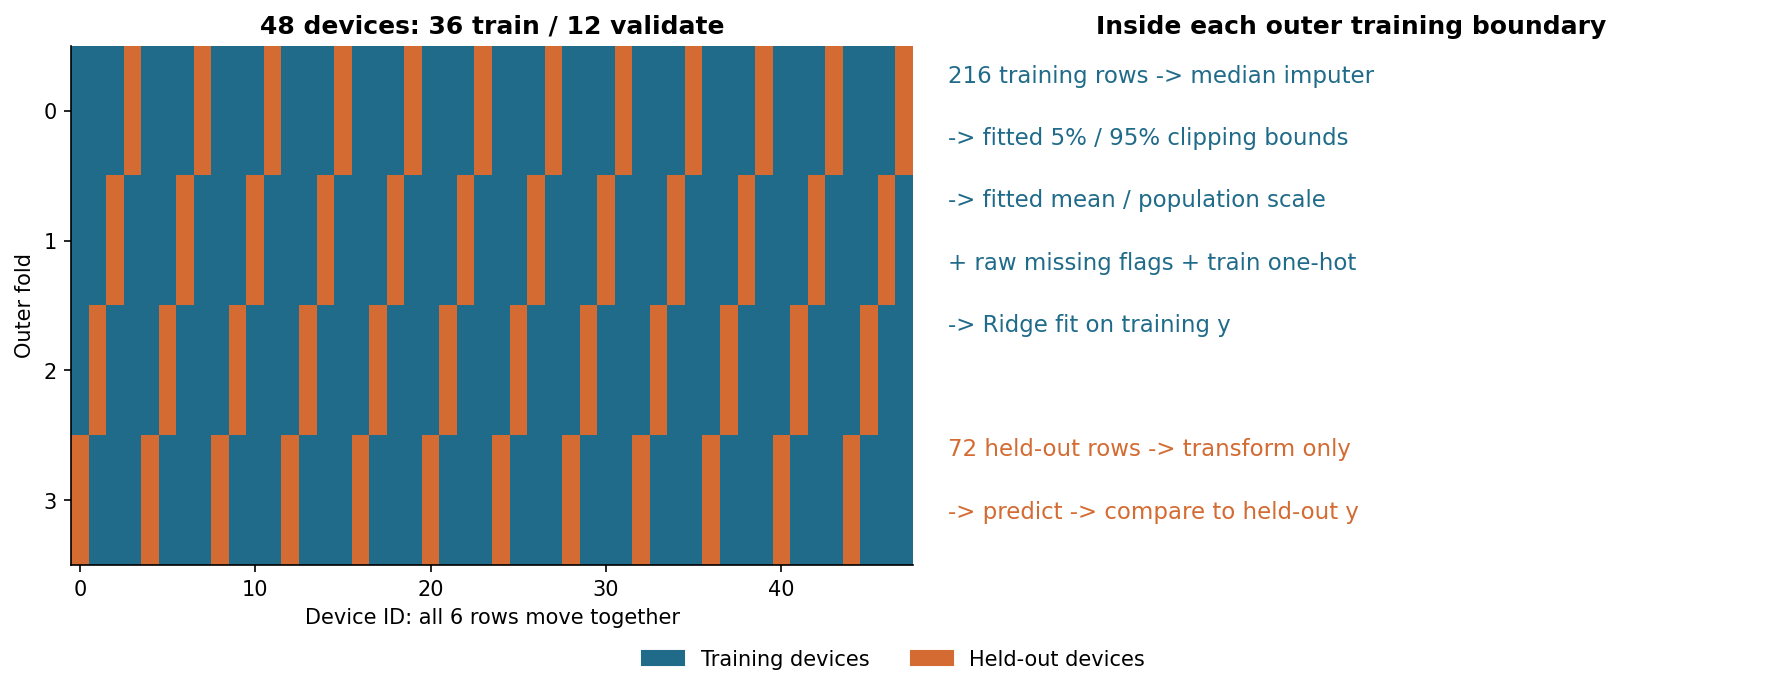

02_numeric_processing


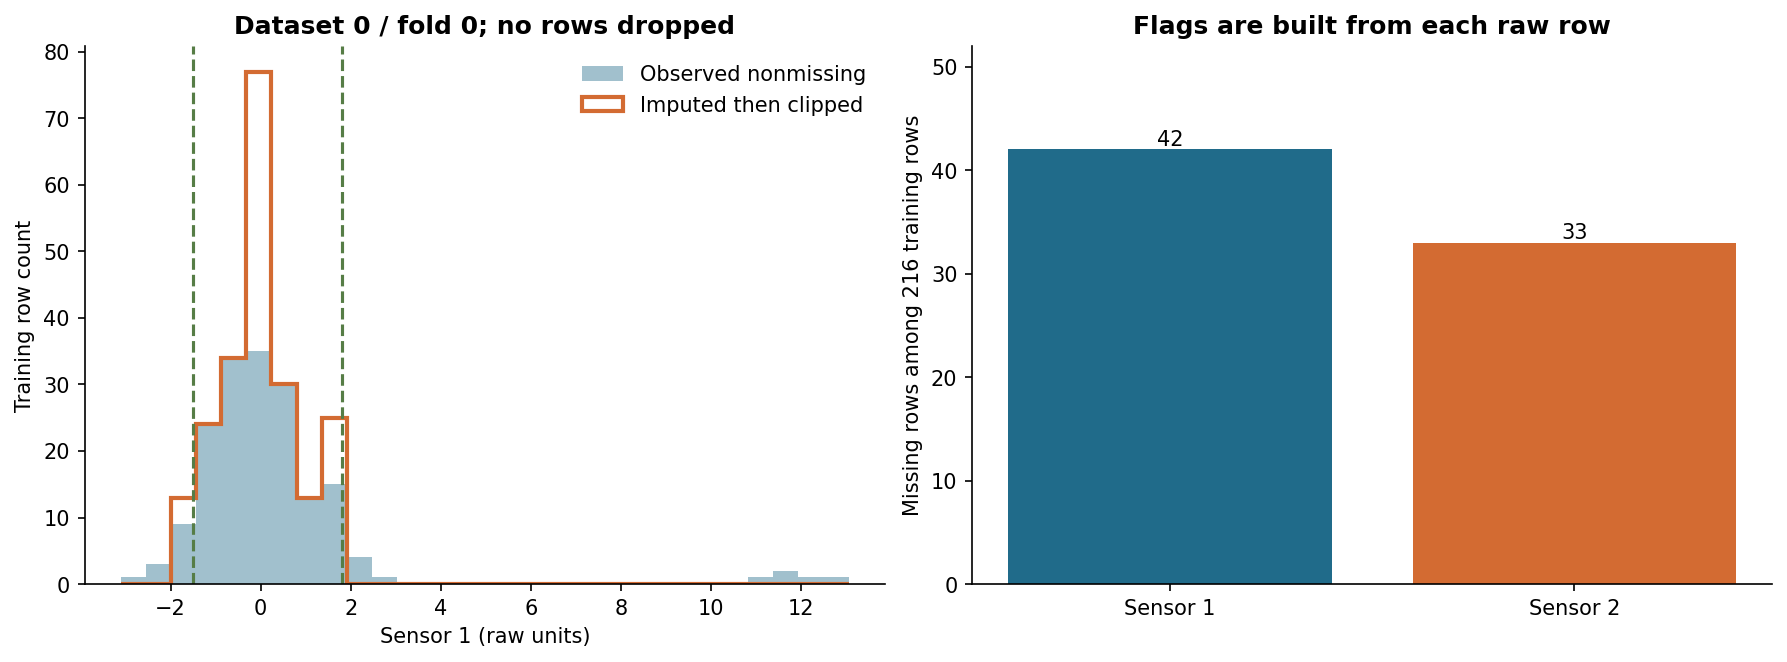

03_hand_preprocessing


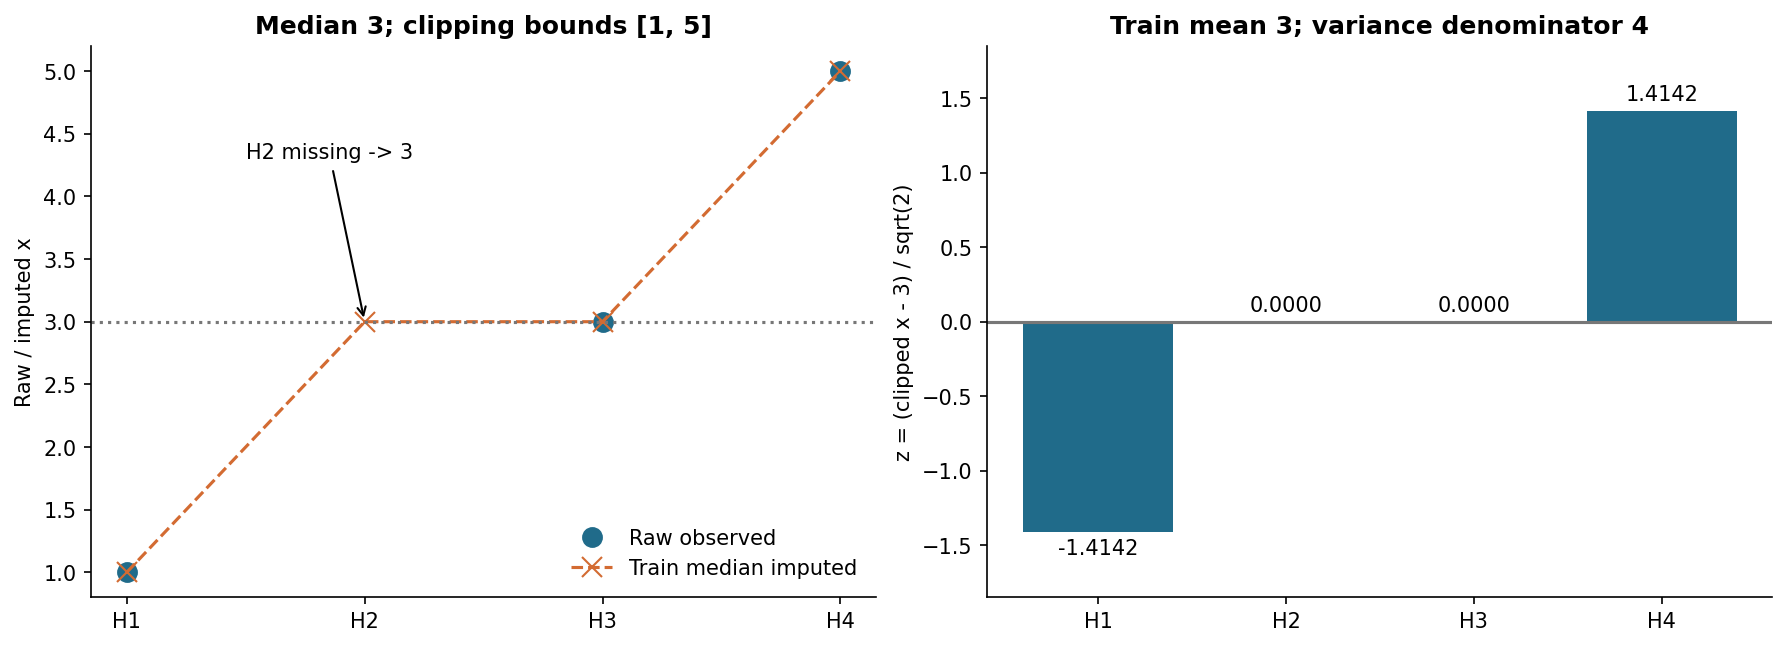

04_hand_gradients


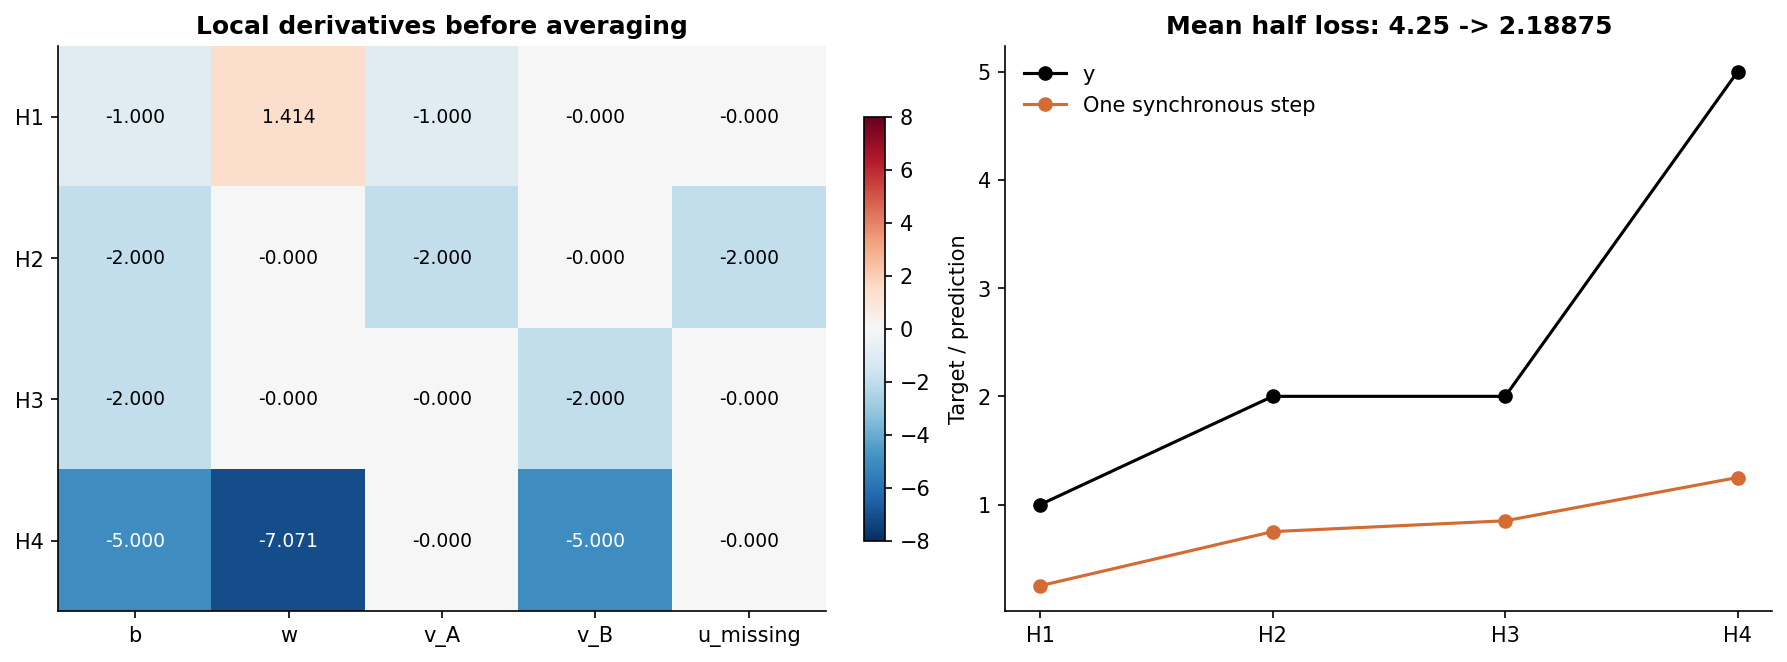

05_scaling_differences


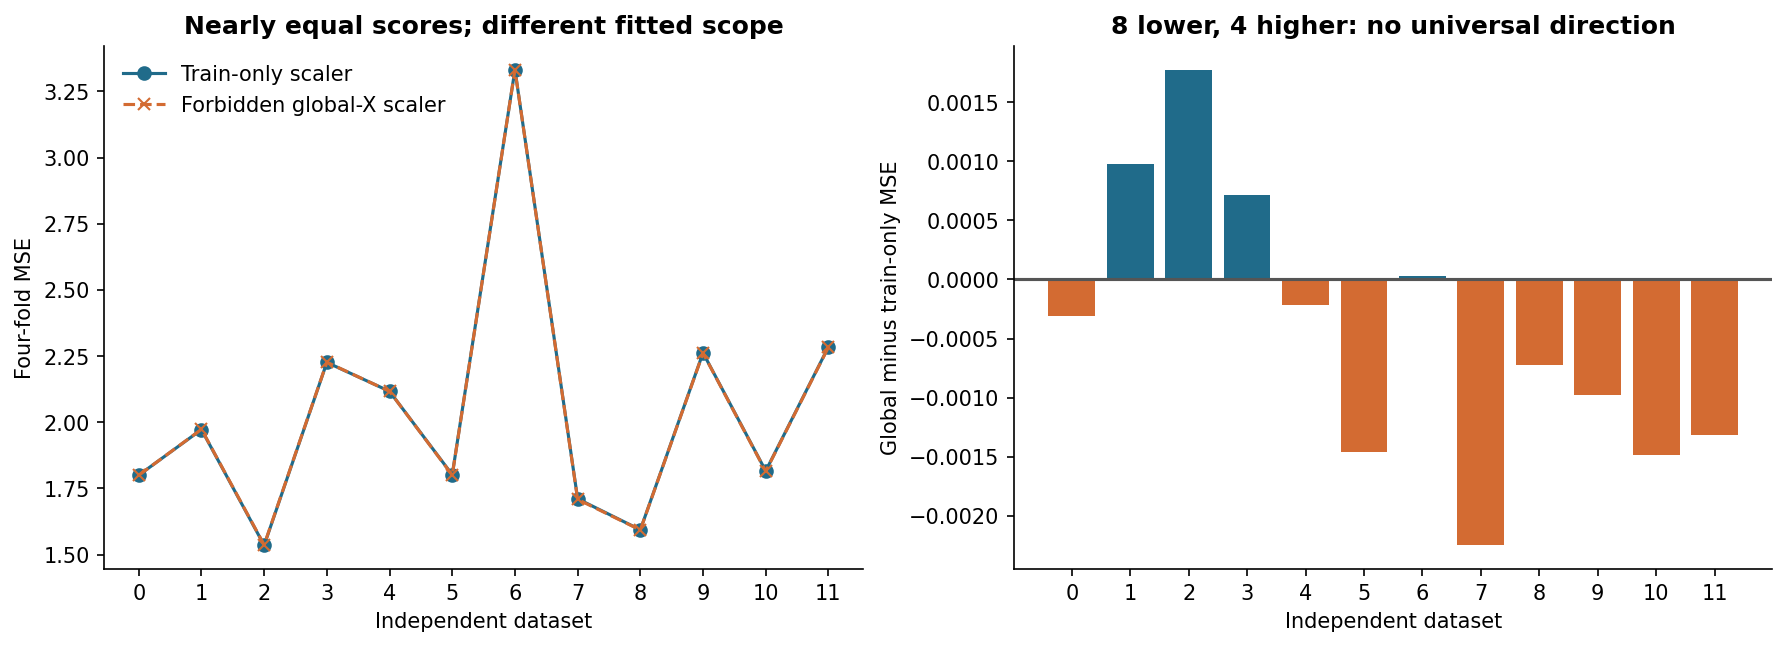

In [12]:
for name in plots.NAMES[:5]:
    print(name)
    display(Image(filename=str(figure_dir/(name+".png"))))

06_affine_control


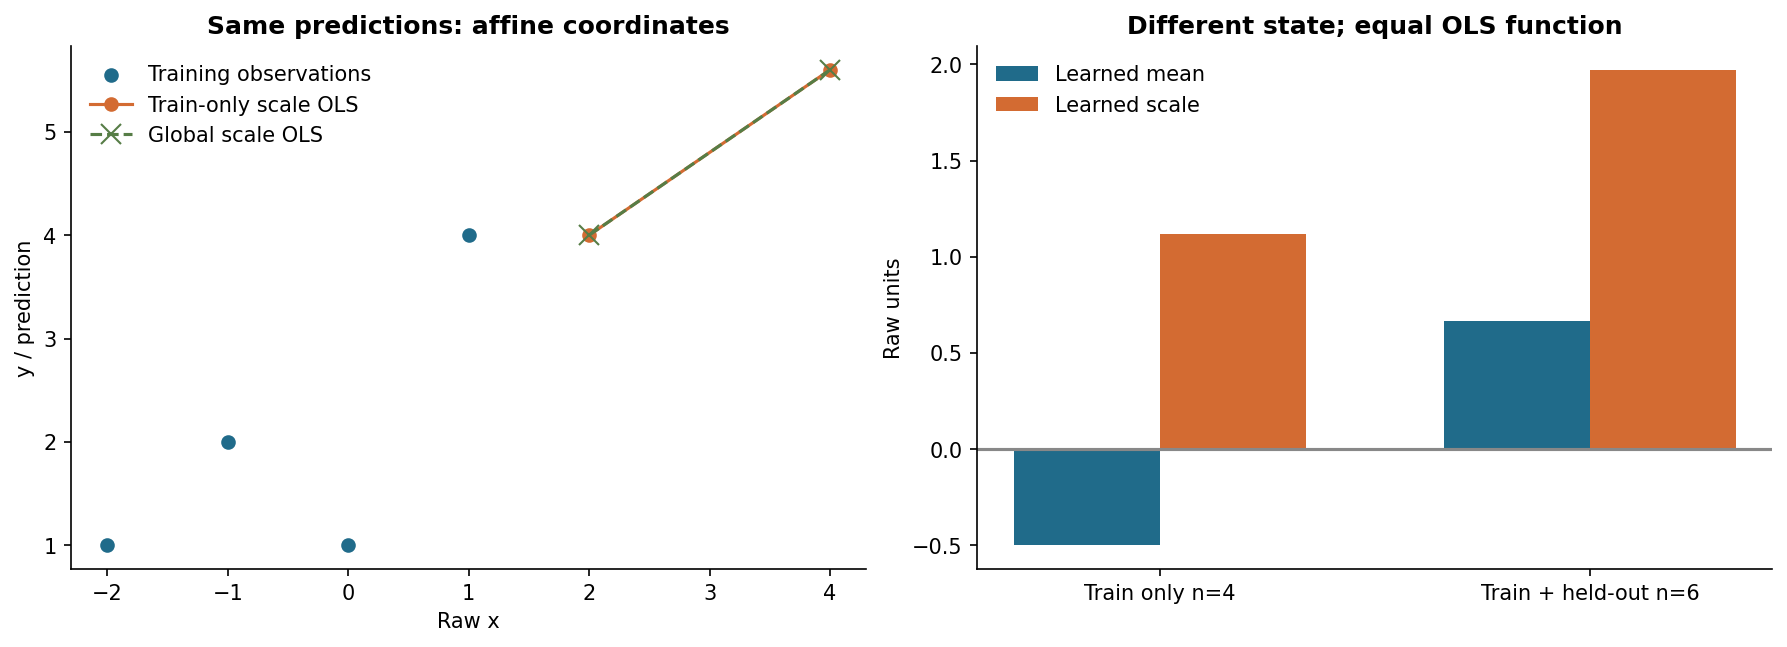

07_feature_selection


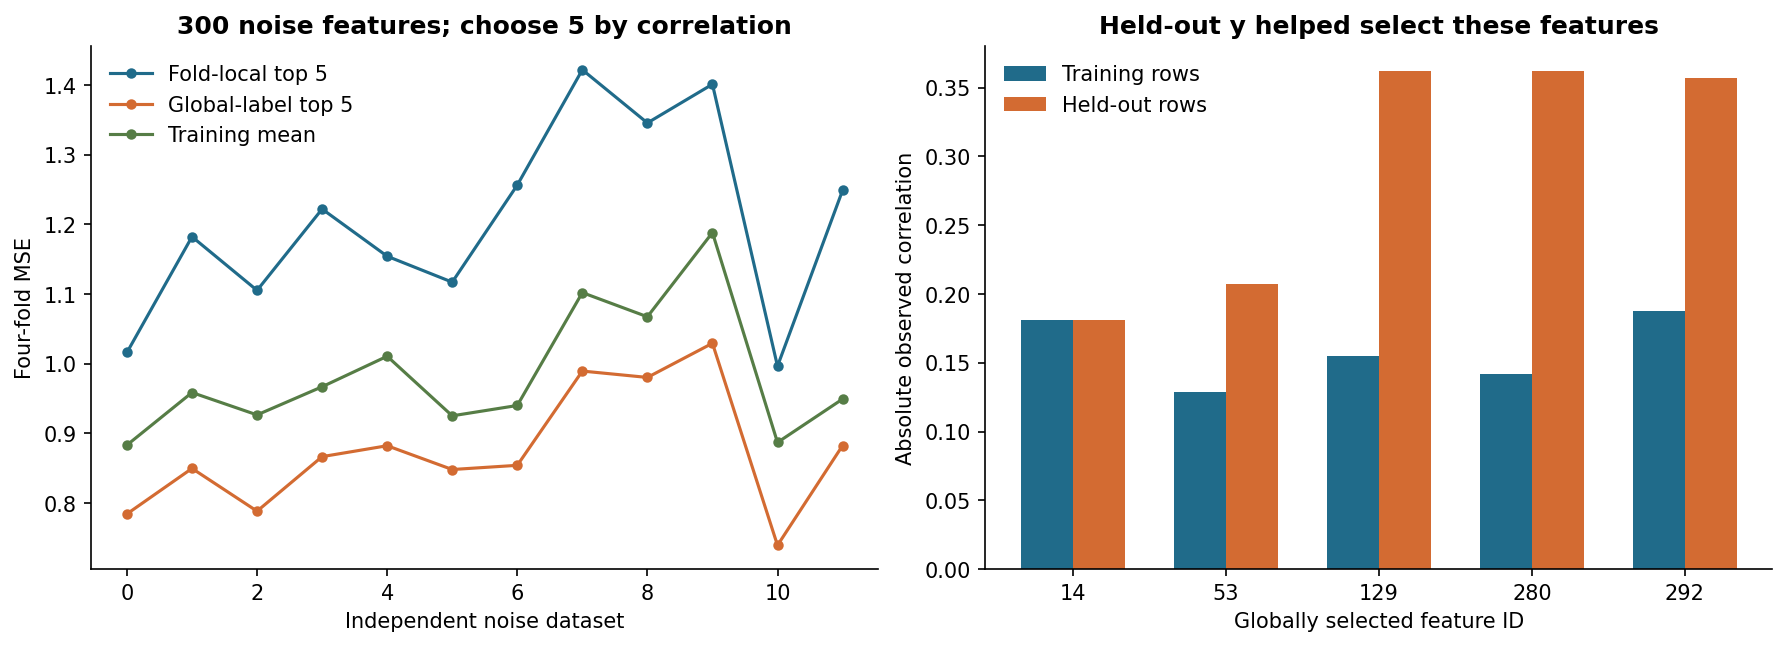

08_encoder_hand


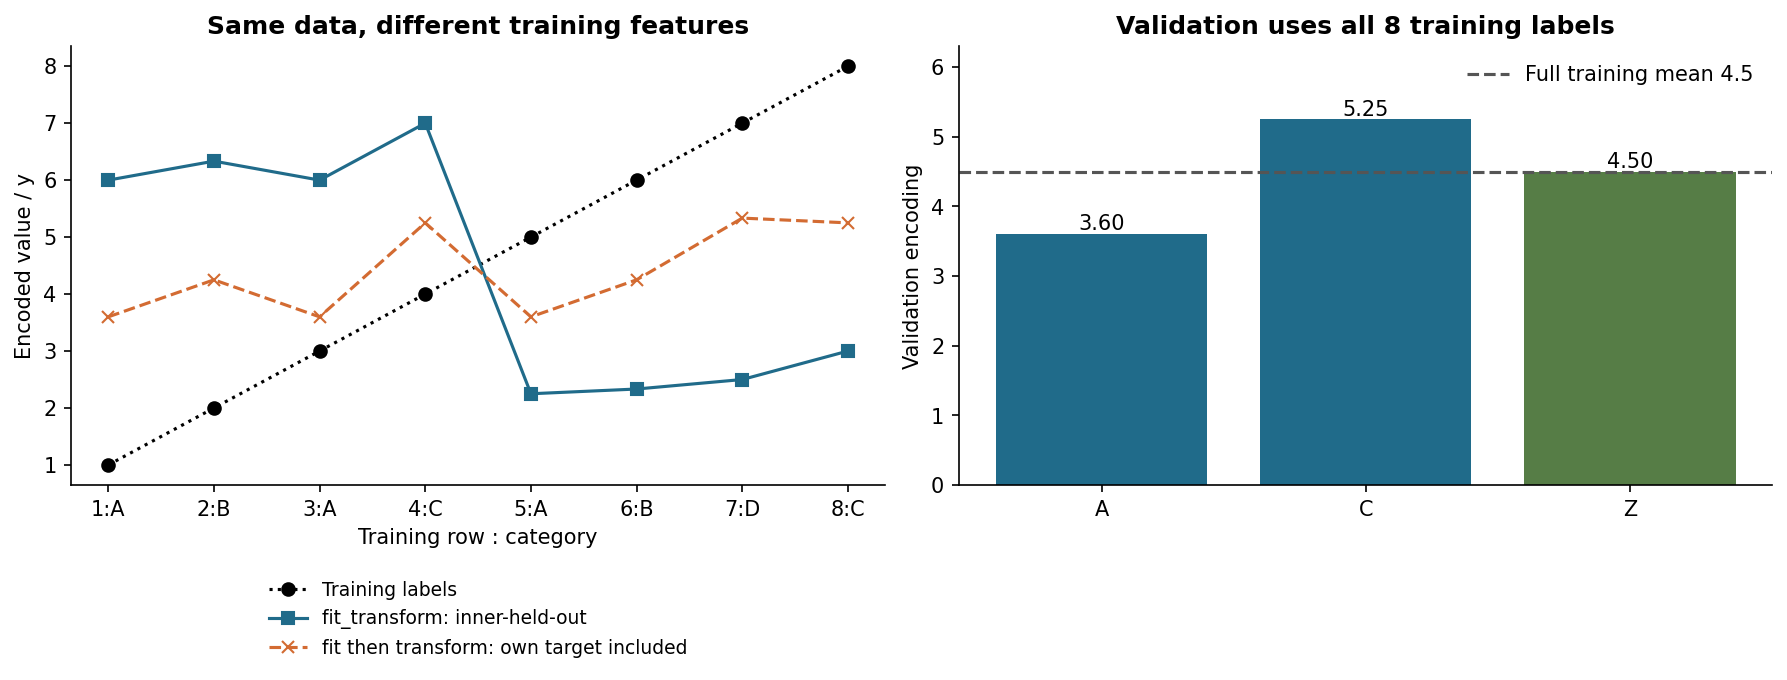

09_encoding_scores


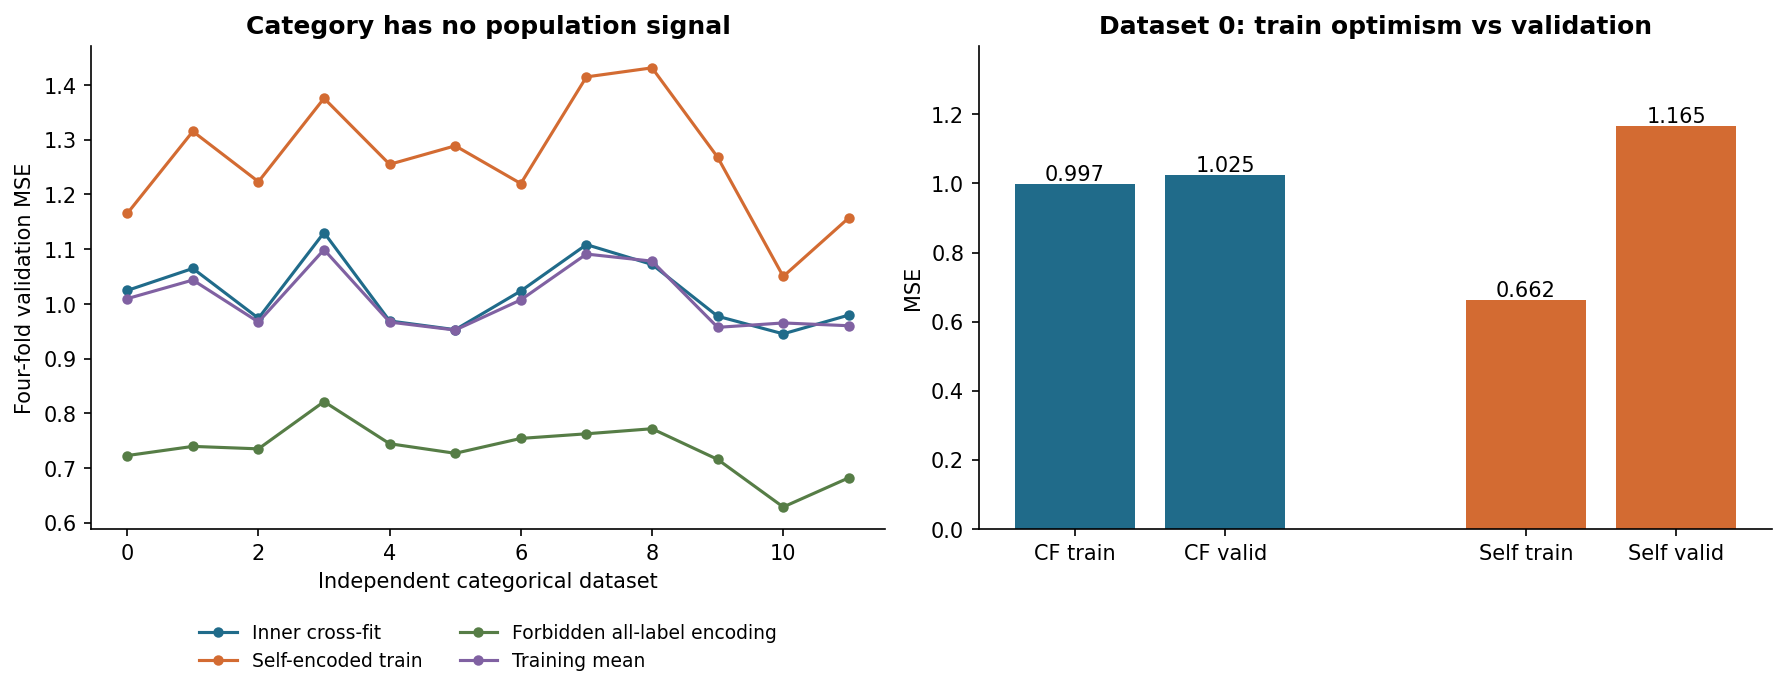

10_inner_provenance


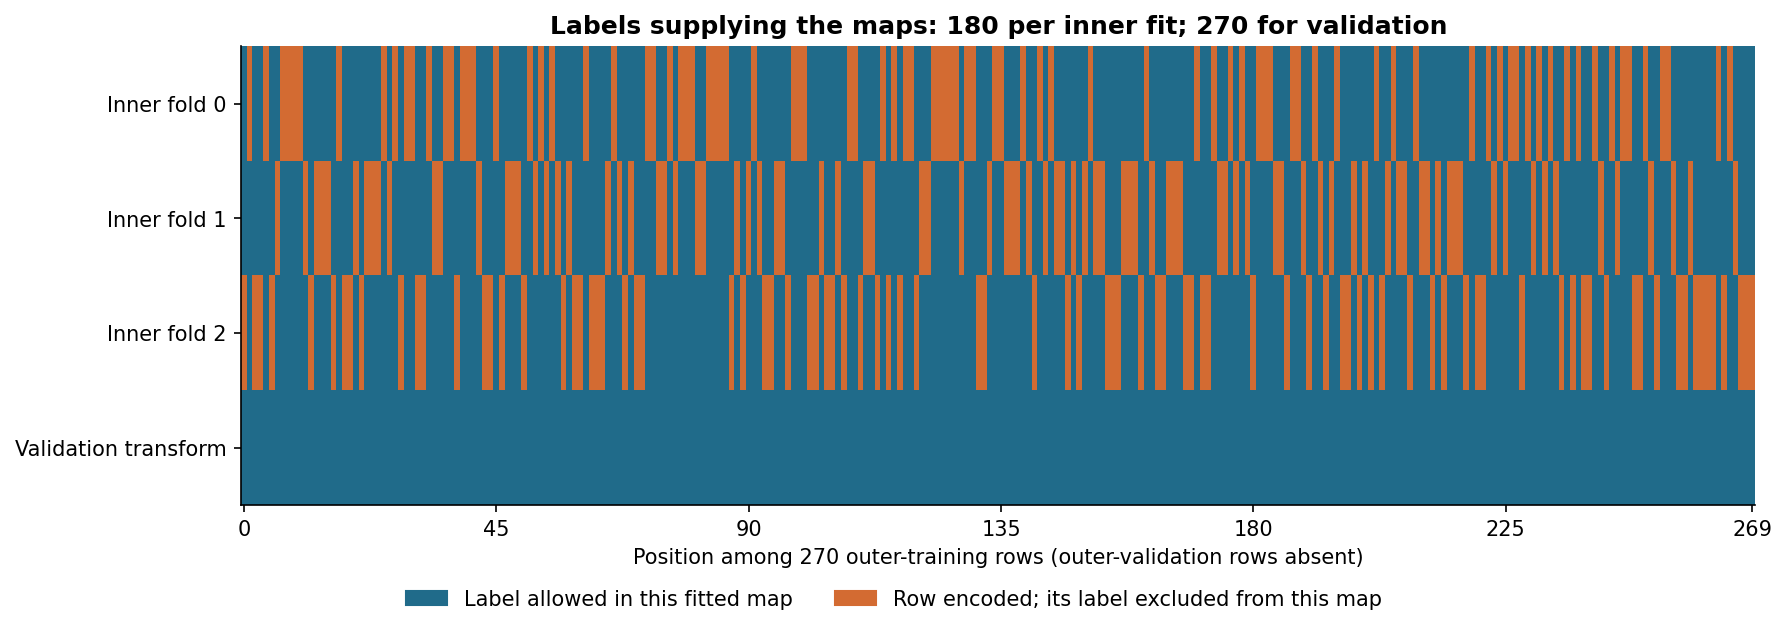

In [13]:
for name in plots.NAMES[5:]:
    print(name)
    display(Image(filename=str(figure_dir/(name+".png"))))

## 11 完成解释

1. A仅改变缩放fit集合，4份变差保留。
2. B选列先读全标签使验证不再独立。
3. C训练自编码过拟合和外层标签泄漏不同。
4. 每个内部均值和类别和都来自允许子集。
5. 本包无现实部署、无时间外推、无新研究pilot结论。

完成E1至E16、G1至G10、L1至L8后对照完整答案。